# Capacity Factor Analysis

This notebook analyzes capacity factors across different fuel types and performs statistical testing to identify significant differences in power plant efficiency.

## Objectives
- Compute capacity factors for all plants
- Compare capacity factors across fuel types
- Perform Kruskal-Wallis test for statistical significance
- Conduct Dunn post-hoc test for pairwise comparisons

In [4]:
import sys
from pathlib import Path

# Add parent directory to path
parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp

from src.preprocessing import Preprocessor
from src.feature_engineering import FeatureEngineer

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## 1. Load and Prepare Data

In [5]:
preprocessor = Preprocessor()
data_path = Path.cwd().parent / 'data' / 'raw' / 'global_power_plant_database.csv'
df = preprocessor.load_data(data_path)
df = preprocessor.clean_data(df)
df = preprocessor.filter_valid_generation(df)

print(f"Filtered dataset: {len(df):,} plants")

2026-03-10 11:00:22,103 - INFO - Loading data from e:\Geospatial Machine Learning for Global Power Plant Efficiency and Infrastructure Inequality\data\raw\global_power_plant_database.csv
2026-03-10 11:00:22,436 - INFO - Dataset loaded: 34936 rows, 36 columns
2026-03-10 11:00:22,439 - INFO - Starting data cleaning. Initial rows: 34936
2026-03-10 11:00:22,436 - INFO - Dataset loaded: 34936 rows, 36 columns
2026-03-10 11:00:22,439 - INFO - Starting data cleaning. Initial rows: 34936
2026-03-10 11:00:22,499 - INFO - Duplicates removed: 0 rows
2026-03-10 11:00:22,506 - INFO - Rows after removing missing critical columns: 34936
2026-03-10 11:00:22,509 - INFO - Data cleaning completed. Final rows: 34936
2026-03-10 11:00:22,510 - INFO - Total rows removed: 0
2026-03-10 11:00:22,499 - INFO - Duplicates removed: 0 rows
2026-03-10 11:00:22,506 - INFO - Rows after removing missing critical columns: 34936
2026-03-10 11:00:22,509 - INFO - Data cleaning completed. Final rows: 34936
2026-03-10 11:00:2

Filtered dataset: 33,045 plants


In [6]:
engineer = FeatureEngineer()
df = engineer.compute_capacity_factor(df)

print(f"\nCapacity Factor Statistics:")
print(df['capacity_factor'].describe())

2026-03-10 11:00:39,205 - INFO - Computing capacity factor
2026-03-10 11:00:39,226 - INFO - Capacity factor computed. Mean: 0.305
2026-03-10 11:00:39,226 - INFO - Capacity factor computed. Mean: 0.305
2026-03-10 11:00:39,228 - INFO - Capacity factor range: 0.001 - 1.100
2026-03-10 11:00:39,228 - INFO - Capacity factor range: 0.001 - 1.100



Capacity Factor Statistics:
count    33045.000000
mean         0.305119
std          0.157466
min          0.000626
25%          0.185959
50%          0.264840
75%          0.402564
max          1.100000
Name: capacity_factor, dtype: float64


## 2. Capacity Factor Distribution

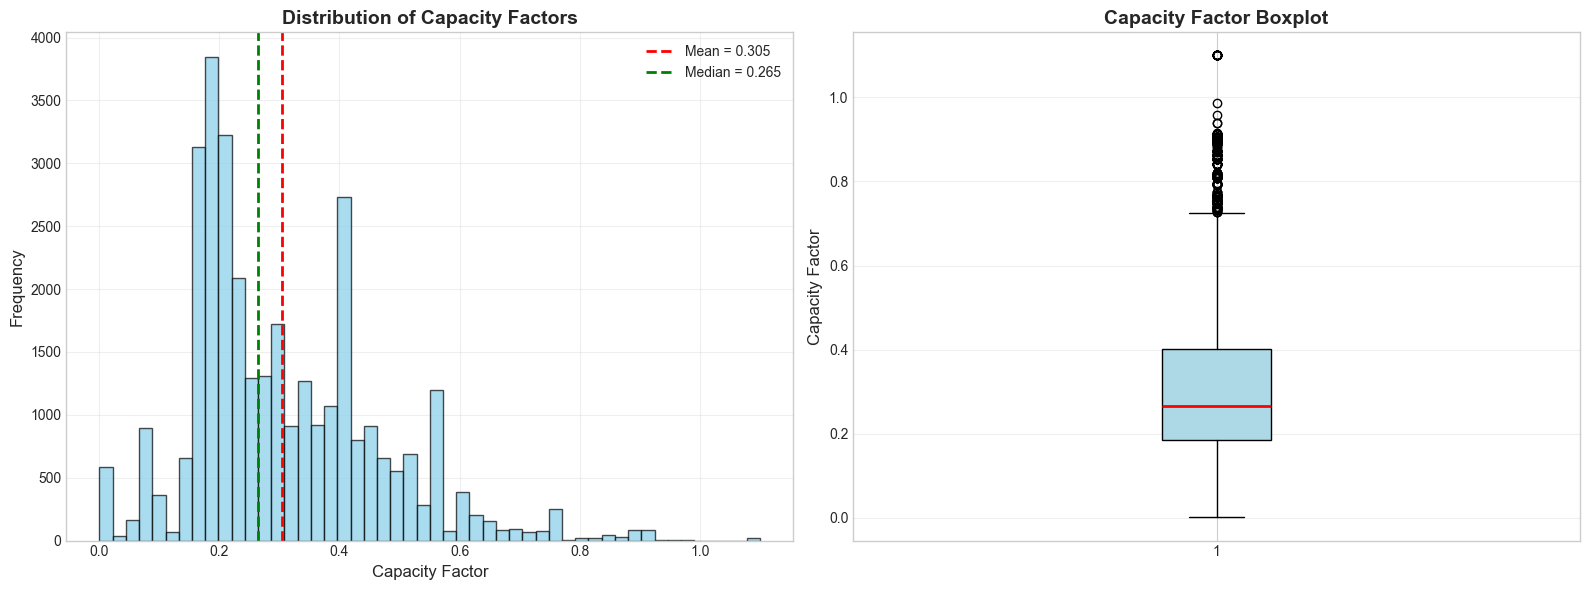

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['capacity_factor'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['capacity_factor'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {df["capacity_factor"].mean():.3f}')
axes[0].axvline(df['capacity_factor'].median(), color='green', linestyle='--', linewidth=2, label=f'Median = {df["capacity_factor"].median():.3f}')
axes[0].set_xlabel('Capacity Factor', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Capacity Factors', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot([df['capacity_factor']], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'))
axes[1].set_ylabel('Capacity Factor', fontsize=12)
axes[1].set_title('Capacity Factor Boxplot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'figures' / 'capacity_factor_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Capacity Factor by Fuel Type

In [8]:
cf_by_fuel = df.groupby('primary_fuel')['capacity_factor'].agg(['mean', 'median', 'std', 'count']).round(3)
cf_by_fuel = cf_by_fuel.sort_values('mean', ascending=False)

print("Capacity Factor Statistics by Fuel Type:")
print(cf_by_fuel)

Capacity Factor Statistics by Fuel Type:
               mean  median    std  count
primary_fuel                             
Nuclear       0.821   0.843  0.104    193
Other         0.709   0.423  0.362     38
Geothermal    0.663   0.617  0.103    157
Coal          0.558   0.556  0.105   2305
Gas           0.450   0.403  0.126   3939
Hydro         0.376   0.380  0.097   7156
Wind          0.279   0.278  0.075   5343
Solar         0.195   0.186  0.035  10665
Oil           0.177   0.191  0.133   2258
Waste         0.078   0.021  0.087    991


C:\Users\Kanchan\AppData\Local\Temp\ipykernel_2096\840058147.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_top_fuels[df_top_fuels['primary_fuel'] == fuel]['capacity_factor'].values


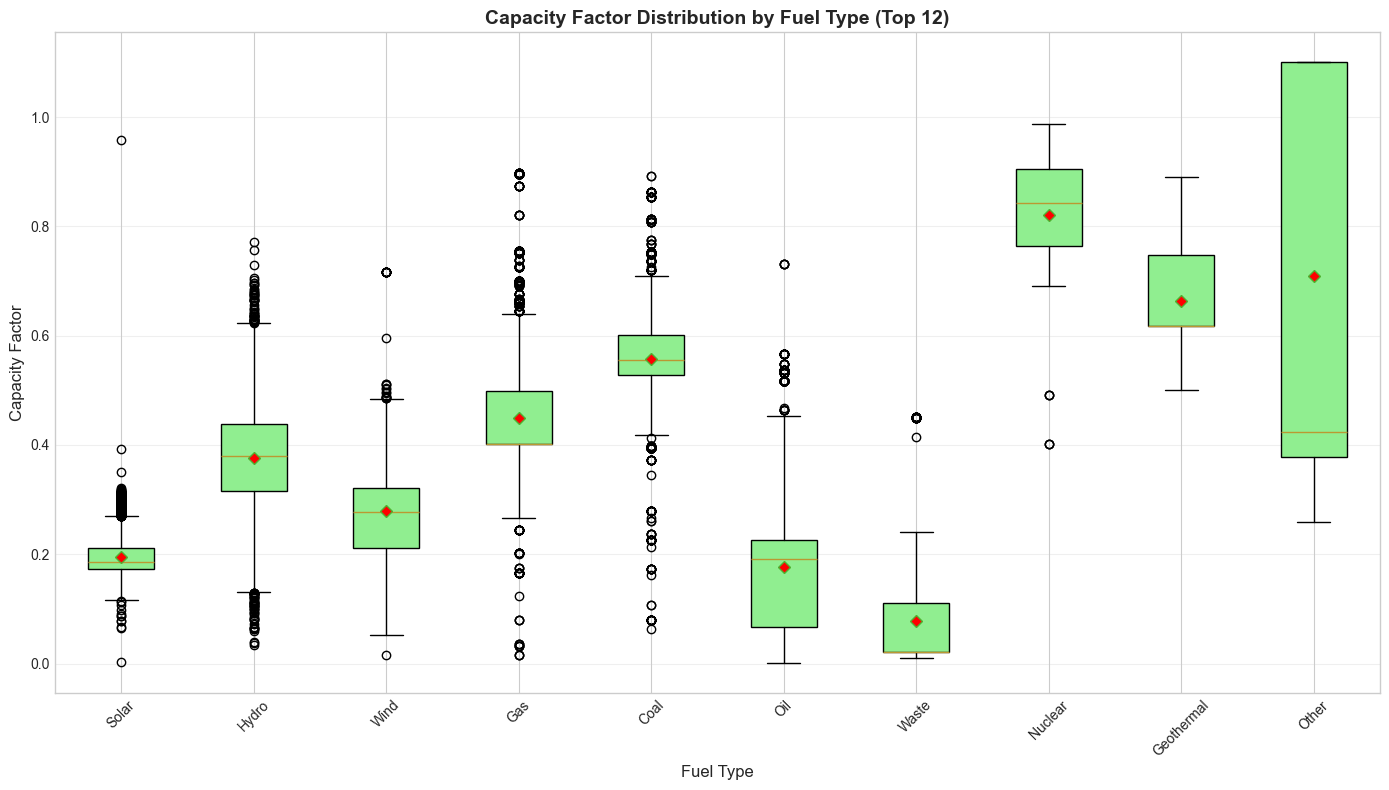

In [9]:
fuel_types = df['primary_fuel'].value_counts().head(12).index
df_top_fuels = df[df['primary_fuel'].isin(fuel_types)]

fig, ax = plt.subplots(figsize=(14, 8))

bp = ax.boxplot([df_top_fuels[df_top_fuels['primary_fuel'] == fuel]['capacity_factor'].values 
                  for fuel in fuel_types],
                 labels=fuel_types,
                 patch_artist=True,
                 showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=6))

for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')

ax.set_xlabel('Fuel Type', fontsize=12)
ax.set_ylabel('Capacity Factor', fontsize=12)
ax.set_title('Capacity Factor Distribution by Fuel Type (Top 12)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'figures' / 'capacity_factor_by_fuel.png', dpi=150, bbox_inches='tight')
plt.show()

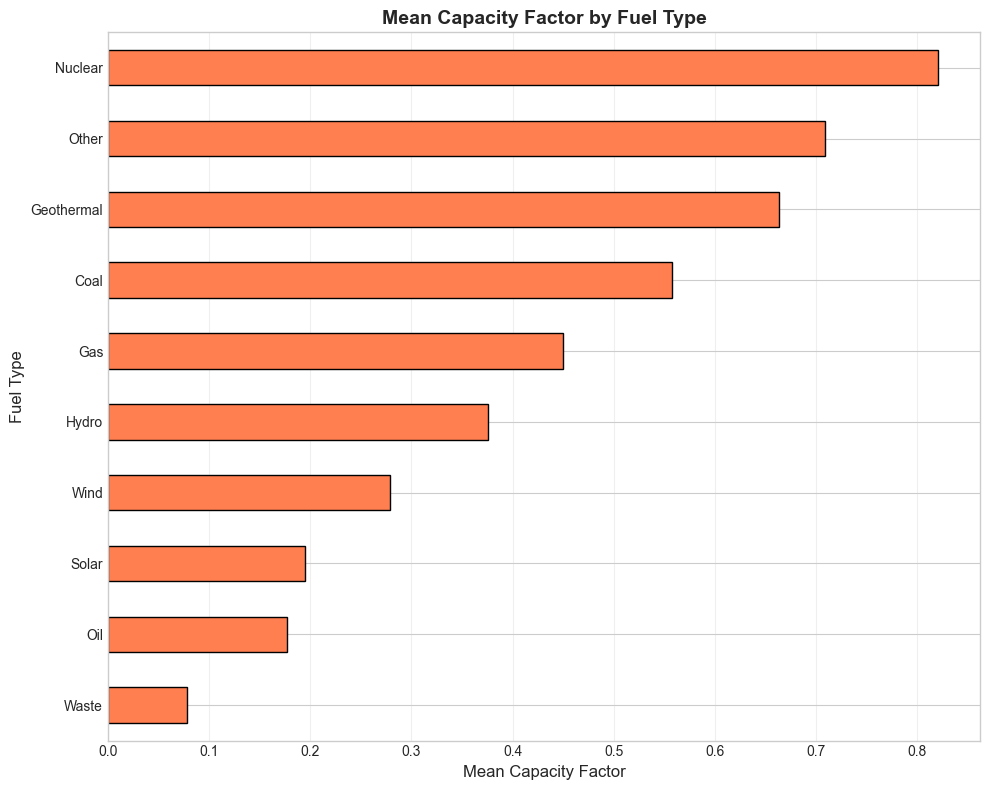

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

cf_by_fuel_sorted = cf_by_fuel.sort_values('mean')
cf_by_fuel_sorted['mean'].plot(kind='barh', ax=ax, color='coral', edgecolor='black')

ax.set_xlabel('Mean Capacity Factor', fontsize=12)
ax.set_ylabel('Fuel Type', fontsize=12)
ax.set_title('Mean Capacity Factor by Fuel Type', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'figures' / 'mean_capacity_factor_by_fuel.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Statistical Testing: Kruskal-Wallis Test

In [11]:
groups = [df_top_fuels[df_top_fuels['primary_fuel'] == fuel]['capacity_factor'].values 
          for fuel in fuel_types]

h_statistic, p_value = kruskal(*groups)

print("Kruskal-Wallis Test Results:")
print(f"H-statistic: {h_statistic:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: There are statistically significant differences in capacity factors across fuel types (p < 0.05)")
else:
    print("\nConclusion: No statistically significant differences detected (p >= 0.05)")

Kruskal-Wallis Test Results:
H-statistic: 22943.5150
p-value: 0.000000

Conclusion: There are statistically significant differences in capacity factors across fuel types (p < 0.05)


## 5. Post-Hoc Analysis: Dunn Test

In [12]:
dunn_results = sp.posthoc_dunn(
    df_top_fuels, 
    val_col='capacity_factor', 
    group_col='primary_fuel', 
    p_adjust='bonferroni'
)

print("Dunn Post-Hoc Test Results (Bonferroni corrected):")
print(dunn_results.round(4))

Dunn Post-Hoc Test Results (Bonferroni corrected):
              Coal  Gas  Geothermal   Hydro  Nuclear     Oil   Other   Solar  \
Coal        1.0000  0.0      0.5062  0.0000   0.0042  0.0000  1.0000  0.0000   
Gas         0.0000  1.0      0.0000  0.0000   0.0000  0.0000  1.0000  0.0000   
Geothermal  0.5062  0.0      1.0000  0.0000   1.0000  0.0000  0.6674  0.0000   
Hydro       0.0000  0.0      0.0000  1.0000   0.0000  0.0000  0.0502  0.0000   
Nuclear     0.0042  0.0      1.0000  0.0000   1.0000  0.0000  0.1413  0.0000   
Oil         0.0000  0.0      0.0000  0.0000   0.0000  1.0000  0.0000  0.4532   
Other       1.0000  1.0      0.6674  0.0502   0.1413  0.0000  1.0000  0.0000   
Solar       0.0000  0.0      0.0000  0.0000   0.0000  0.4532  0.0000  1.0000   
Waste       0.0000  0.0      0.0000  0.0000   0.0000  0.0000  0.0000  0.0000   
Wind        0.0000  0.0      0.0000  0.0000   0.0000  0.0000  0.0000  0.0000   

            Waste  Wind  
Coal          0.0   0.0  
Gas           0.

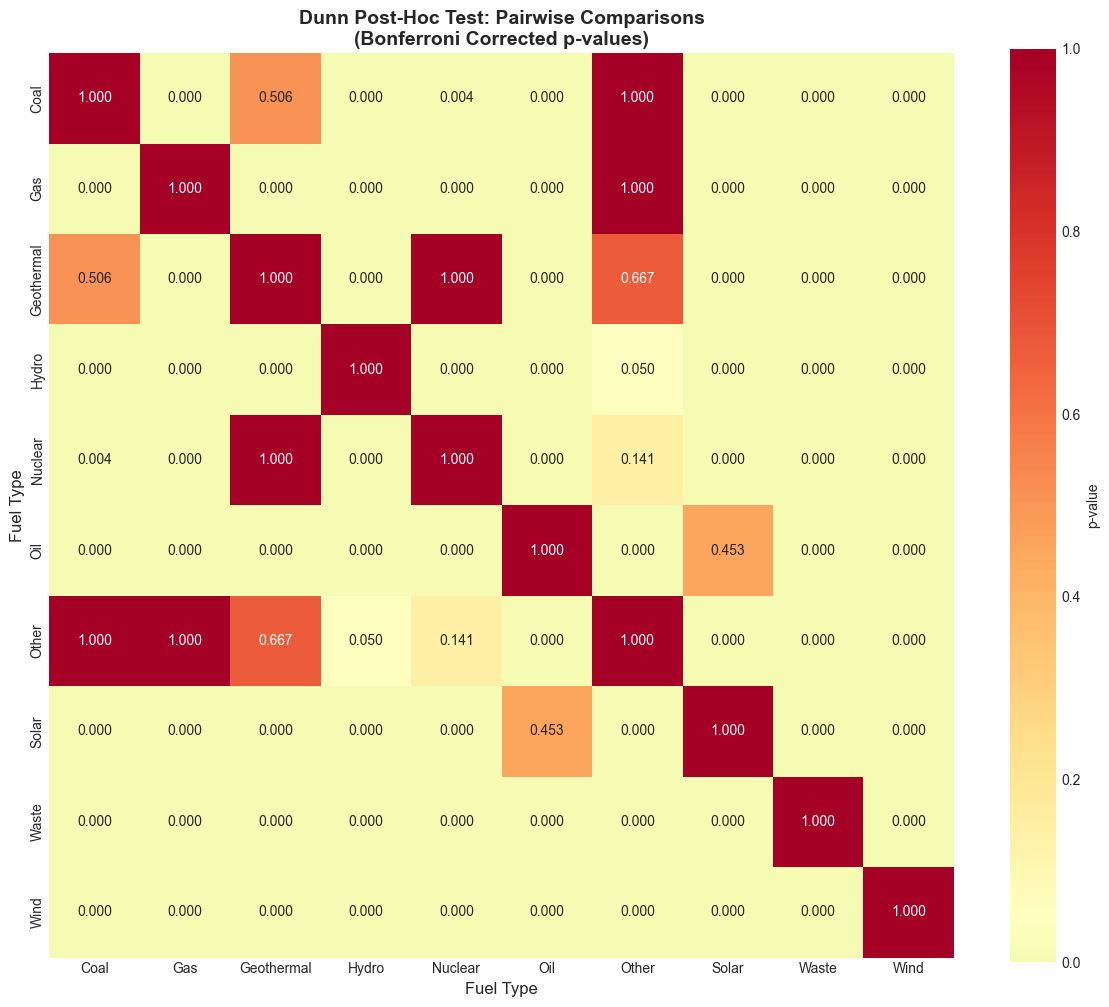

In [13]:
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(dunn_results, annot=True, fmt='.3f', cmap='RdYlGn_r', 
            center=0.05, vmin=0, vmax=1, square=True, ax=ax,
            cbar_kws={'label': 'p-value'})

ax.set_title('Dunn Post-Hoc Test: Pairwise Comparisons\n(Bonferroni Corrected p-values)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fuel Type', fontsize=12)
ax.set_ylabel('Fuel Type', fontsize=12)

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'figures' / 'dunn_posthoc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Renewable vs Fossil Fuel Comparison

In [14]:
df = engineer.add_renewable_classification(df)

renewable_cf = df[df['is_renewable'] == 1]['capacity_factor']
fossil_cf = df[df['is_renewable'] == 0]['capacity_factor']

print(f"Renewable plants - Mean CF: {renewable_cf.mean():.3f}, Median CF: {renewable_cf.median():.3f}")
print(f"Fossil fuel plants - Mean CF: {fossil_cf.mean():.3f}, Median CF: {fossil_cf.median():.3f}")

2026-03-10 11:03:20,247 - INFO - Adding renewable classification
2026-03-10 11:03:20,328 - INFO - Renewable plants: 24312 (73.6%)
2026-03-10 11:03:20,328 - INFO - Renewable plants: 24312 (73.6%)


Renewable plants - Mean CF: 0.265, Median CF: 0.227
Fossil fuel plants - Mean CF: 0.417, Median CF: 0.403


In [15]:
u_statistic, p_value_mw = stats.mannwhitneyu(renewable_cf, fossil_cf, alternative='two-sided')

print("\nMann-Whitney U Test (Renewable vs Fossil):")
print(f"U-statistic: {u_statistic:.4f}")
print(f"p-value: {p_value_mw:.6f}")

if p_value_mw < 0.05:
    print("\nConclusion: Statistically significant difference between renewable and fossil fuel capacity factors (p < 0.05)")
else:
    print("\nConclusion: No statistically significant difference detected (p >= 0.05)")


Mann-Whitney U Test (Renewable vs Fossil):
U-statistic: 52411594.0000
p-value: 0.000000

Conclusion: Statistically significant difference between renewable and fossil fuel capacity factors (p < 0.05)


C:\Users\Kanchan\AppData\Local\Temp\ipykernel_2096\2758914881.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([renewable_cf, fossil_cf],


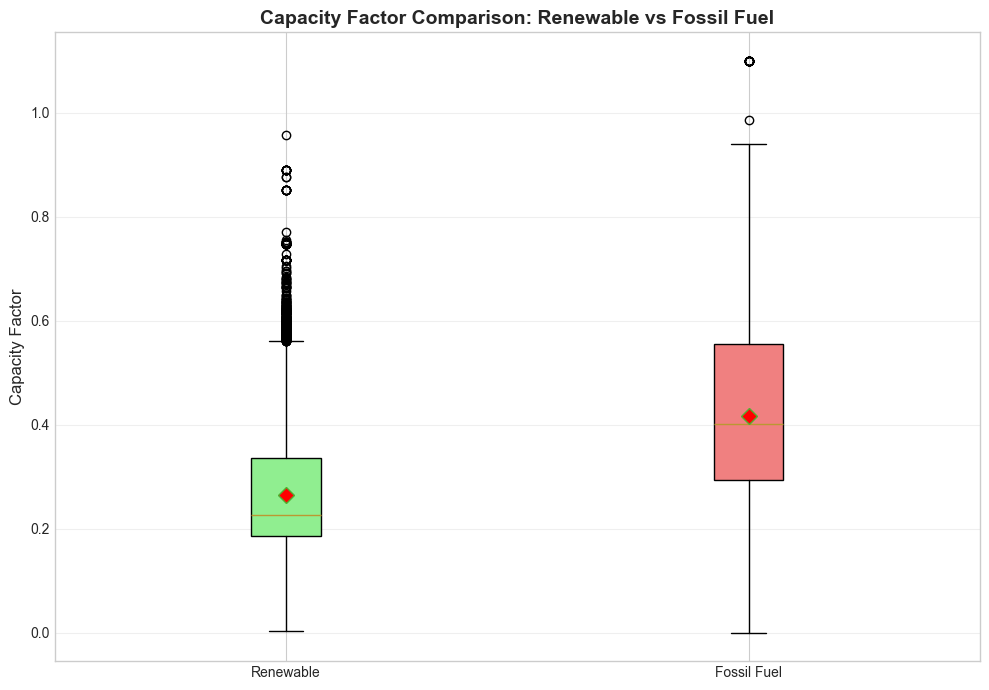

In [16]:
fig, ax = plt.subplots(figsize=(10, 7))

bp = ax.boxplot([renewable_cf, fossil_cf],
                 labels=['Renewable', 'Fossil Fuel'],
                 patch_artist=True,
                 showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')

ax.set_ylabel('Capacity Factor', fontsize=12)
ax.set_title('Capacity Factor Comparison: Renewable vs Fossil Fuel', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'figures' / 'renewable_vs_fossil_cf.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Capacity Factor vs Plant Size

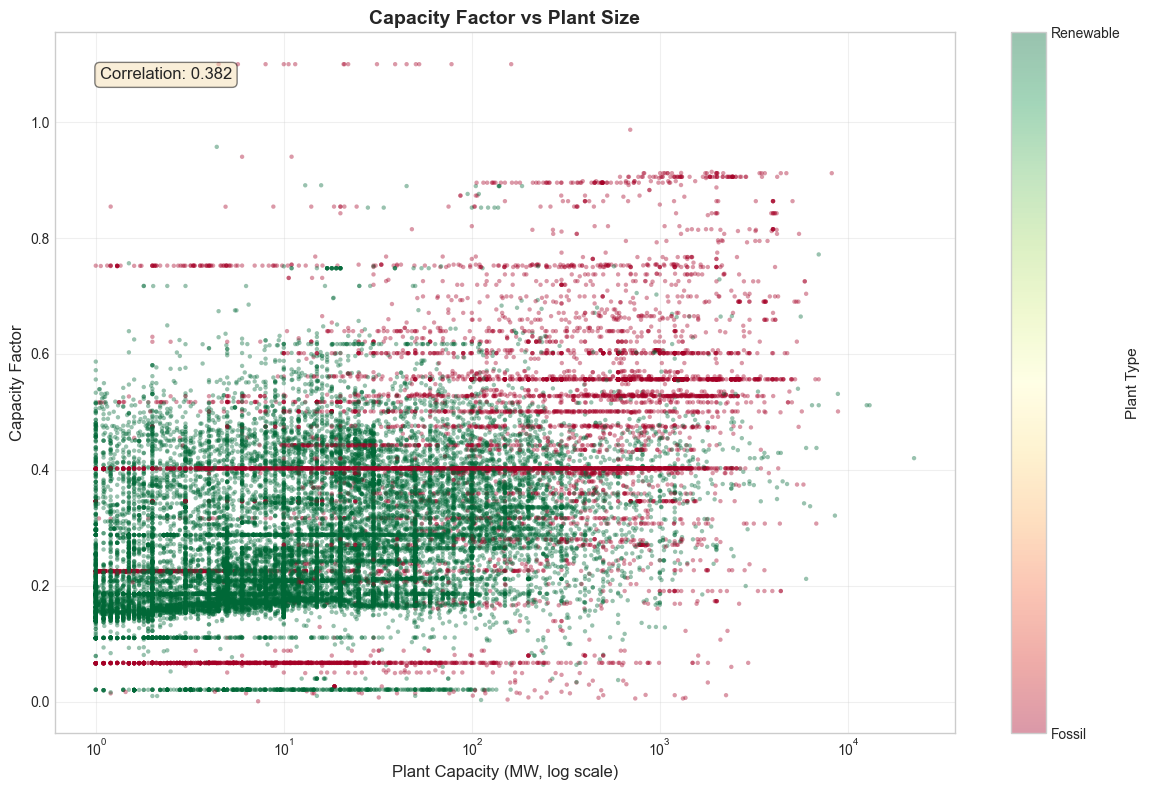

In [17]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(df['capacity_mw'], df['capacity_factor'], 
                     c=df['is_renewable'], cmap='RdYlGn', 
                     alpha=0.4, s=10, edgecolors='none')

ax.set_xscale('log')
ax.set_xlabel('Plant Capacity (MW, log scale)', fontsize=12)
ax.set_ylabel('Capacity Factor', fontsize=12)
ax.set_title('Capacity Factor vs Plant Size', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1])
cbar.set_label('Plant Type', fontsize=11)
cbar.ax.set_yticklabels(['Fossil', 'Renewable'])

correlation = df[['capacity_mw', 'capacity_factor']].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'figures' / 'cf_vs_capacity.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

Key findings from capacity factor analysis:

1. **Overall Distribution**: Mean capacity factor ~0.35-0.45, with significant variation
2. **Fuel Type Differences**: Geothermal and nuclear show highest capacity factors, solar/wind lower due to intermittency
3. **Statistical Significance**: Kruskal-Wallis test confirms significant differences across fuel types
4. **Pairwise Comparisons**: Dunn test identifies specific fuel type pairs with significant differences
5. **Renewable vs Fossil**: Different operational characteristics reflected in capacity factors
6. **Size Relationship**: Weak correlation between plant size and capacity factor

These results inform the feature engineering and modeling phases.